In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_mnist = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Unpack the MNIST dataset
(X_train, y_train), (X_test, y_test) = df_mnist

In [5]:
# Print shapes and data types
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")
print(f"y_test shape: {y_test.shape}, dtype: {y_test.dtype}")

X_train shape: (60000, 28, 28), dtype: uint8
y_train shape: (60000,), dtype: uint8
X_test shape: (10000, 28, 28), dtype: uint8
y_test shape: (10000,), dtype: uint8


In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"X_train after normalization: Min={np.min(X_train)}, Max={np.max(X_train)}")
print(f"X_test after normalization: Min={np.min(X_test)}, Max={np.max(X_test)}")

X_train after normalization: Min=0.0, Max=1.0
X_test after normalization: Min=0.0, Max=1.0


In [7]:
num_classes = 10 # MNIST has digits 0-9
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"y_train shape after one-hot encoding: {y_train.shape}")
print(f"y_test shape after one-hot encoding: {y_test.shape}")
print(f"First 5 y_train labels after one-hot encoding:\n{y_train[:5]}")

y_train shape after one-hot encoding: (60000, 10)
y_test shape after one-hot encoding: (10000, 10)
First 5 y_train labels after one-hot encoding:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


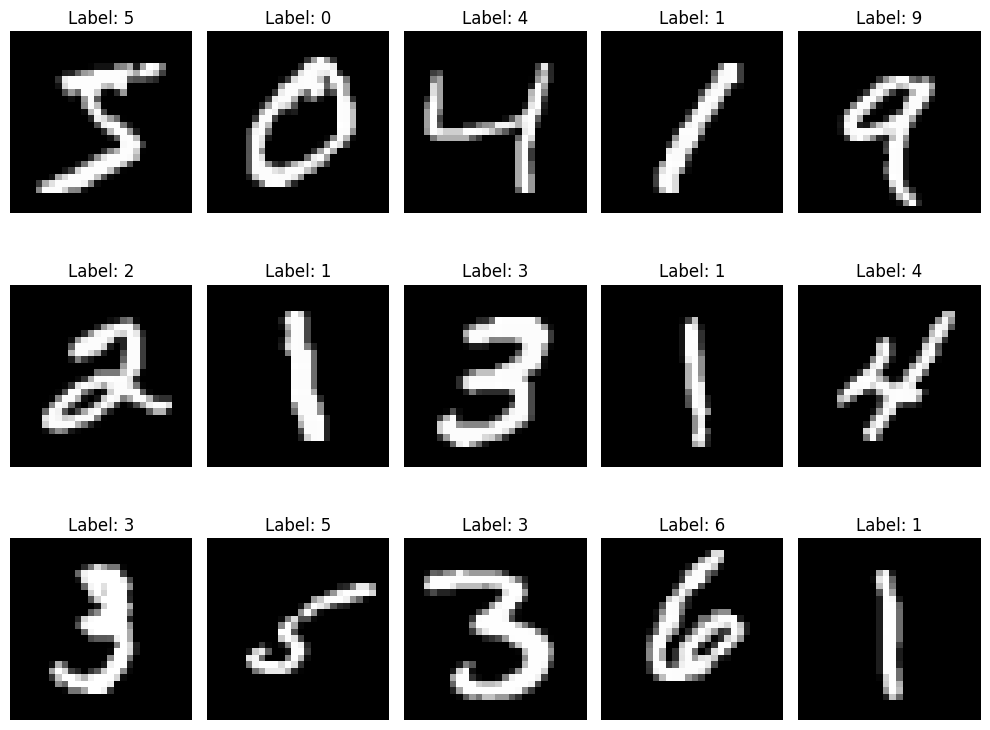

In [8]:
plt.figure(figsize=(10, 8))
for i in range(15): # Display 15 images
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    # To get the original label, we find the index of the '1' in the one-hot encoded array
    original_label = np.argmax(y_train[i])
    plt.title(f"Label: {original_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape

# Define input shape
input_shape = (28, 28, 1) # MNIST images are 28x28 with 1 channel (grayscale)

model_cnn = Sequential([
    # Reshape layer to add the channel dimension
    Reshape(input_shape, input_shape=(28, 28)),

    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten the output for the Dense layers
    Flatten(),

    # Dense layers
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer with 10 classes (0-9) and softmax activation
])

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [11]:
history = model_cnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

print("CNN model training complete!")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9591 - loss: 0.1335 - val_accuracy: 0.9764 - val_loss: 0.0699
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9887 - val_loss: 0.0322
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9906 - loss: 0.0298 - val_accuracy: 0.9880 - val_loss: 0.0391
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9916 - val_loss: 0.0279
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9944 - loss: 0.0167 - val_accuracy: 0.9919 - val_loss: 0.0251
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9963 - loss: 0.0116 - val_accuracy: 0.9891 - val_loss: 0.0377
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9968 - loss: 0.0098 - val_accuracy: 0.9906 - val_loss: 0.0344
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9973 -

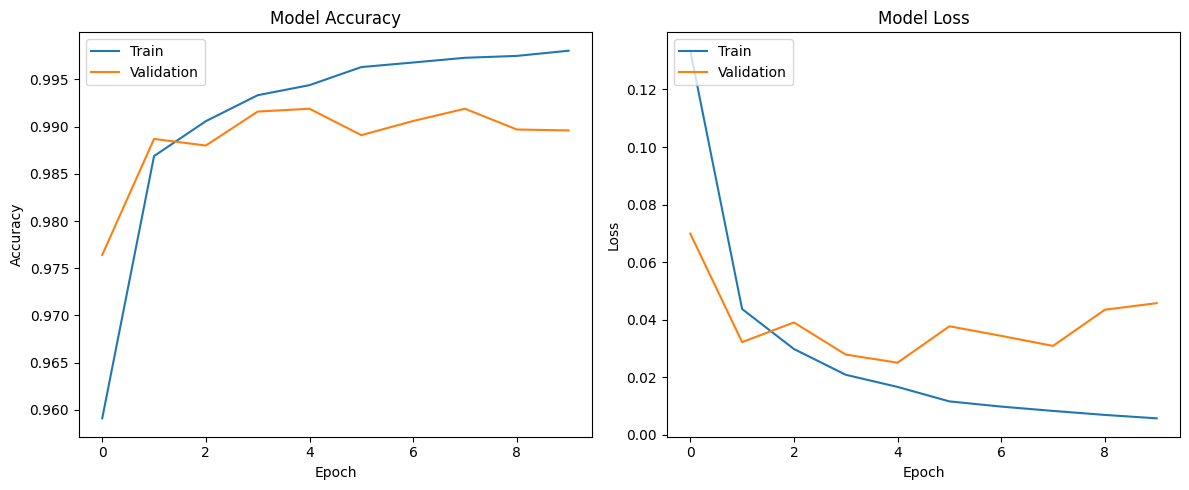

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
loss, accuracy = model_cnn.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0458
Test Accuracy: 0.9896


In [15]:
# Save the model in .h5 format
model_cnn.save('mnist_model.h5')
print("CNN model saved successfully as 'mnist_model.h5'")

CNN model saved successfully as 'mnist_model.h5'
